# Imports

This notebook propagates from `2010-01-01` through the end of `2024` with `phi_targets = [0.0]`.

It uses the standard ballistic solver on a sparse phi axis, so the `phi=0` slice matches the full propagation at the same cadence and model settings.

For long-range fitting throughput, `superresolution_enabled_override` is set to `False` by default here. Set it to `None` to match `Config/SW/Ballistic.json` exactly.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import gc
import os
import sys
import threading
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
from multiprocessing import get_context
from pathlib import Path
from tqdm import tqdm

os.environ.setdefault("MPLCONFIGDIR", "/tmp/helio_n_matplotlib")

cwd = Path.cwd().resolve()
project_root = None
for candidate in (cwd, *cwd.parents, Path("/home/smdc/helio-n")):
    if (candidate / "Library").exists() and (candidate / "Config").exists():
        project_root = candidate
        break
assert (
    project_root is not None
), "Could not locate the helio-n project root for notebook imports."
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
from scipy.optimize import curve_fit

from Library.ICME import drop_icme_periods

from Library.SW.Ballistic import postprocess_max_field, propagate_phi_targets
from Library.SW.CH_SW_Model import EmpiricalCHSWModel
from Library.SW.Config import (
    load_ballistic_spec,
    load_empirical_spec,
    load_sw_runtime_spec,
)
from Library.SW.Coords import compute_rotation_state
from Library.SW.Inputs import (
    build_forecast_earth_frame,
    build_model_input_series,
    load_ace_at_earth,
    load_sw_input_frame,
    load_sw_input_from_sql,
)

In [3]:
start_dt = pd.Timestamp("2025-01-01")
end_dt = pd.Timestamp("2026-01-01")
input_source = "sql"
# input_parquet_path = "Data/CH Area.parquet"
phi_targets = [0.0]
superresolution_enabled_override = True
show_progress = True

print("start_dt:", start_dt)
print("end_dt:", end_dt)
print("phi_targets:", phi_targets)
print("superresolution_enabled_override:", superresolution_enabled_override)


def memory_used_gb():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / 1024**3

start_dt: 2025-01-01 00:00:00
end_dt: 2026-01-01 00:00:00
phi_targets: [0.0]
superresolution_enabled_override: True


In [4]:
empirical_defaults = load_empirical_spec()
empirical_defaults

EmpiricalCHSWModel(source_path=PosixPath('/home/smdc/helio-n/Models/CH_SW_Correspondence/Shugay.py'), v_min=300.0, a=180.0, alpha=0.6)

In [5]:
ballistic = load_ballistic_spec()
runtime = load_sw_runtime_spec()

superresolution_enabled = (
    bool(ballistic["superresolution_enabled"])
    if superresolution_enabled_override is None
    else bool(superresolution_enabled_override)
)
time_step_minutes = (
    int(ballistic["superresolution_step_minutes"])
    if superresolution_enabled
    else int(ballistic["base_time_step_minutes"])
)
time_step_hours = float(time_step_minutes) / 60.0
time_freq = f"{int(time_step_minutes)}min"

df_sdo_sw = load_sw_input_frame(
    start_dt=start_dt,
    end_dt=end_dt,
    source=input_source,
    # input_parquet_path=input_parquet_path,
)

In [6]:
def run_sparse_phi_propagation(
    sdo_input_df,
    ballistic,
    runtime,
    phi_targets,
    superresolution_enabled,
    time_freq,
    time_step_hours,
    slow_sw_speed=300.0,
    a=180.0,
    alpha=0.6,
    show_progress=True,
):
    empirical = EmpiricalCHSWModel.from_fields(
        source_path=project_root / "Models" / "CH_SW_Correspondence" / "Shugay.py",
        v_min=float(slow_sw_speed),
        a=float(a),
        alpha=float(alpha),
    )

    prepared = build_model_input_series(
        sdo_input_df=sdo_input_df,
        empirical=empirical,
        superresolution_enabled=superresolution_enabled,
        time_freq=time_freq,
        simulation_pad_days=ballistic["simulation_pad_days"],
    )
    rotation = compute_rotation_state(
        cr_days=ballistic["cr_days"],
        phi_step_minutes=ballistic["phi_step_minutes"],
    )
    df_v_run = (
        prepared["df_v"]
        .loc[
            (prepared["df_v"].index >= prepared["sim_start"])
            & (prepared["df_v"].index <= prepared["sim_end"])
        ]
        .copy()
    )

    phi_run = propagate_phi_targets(
        df_v_run=df_v_run,
        sim_start=prepared["sim_start"],
        sim_end=prepared["sim_end"],
        time_freq=time_freq,
        rotation_state=rotation,
        r0=ballistic["r0"],
        r_max=ballistic["r_max"],
        dense_memory_budget_gb=runtime["dense_memory_budget_gb"],
        memory_guard_enabled=ballistic["memory_guard_enabled"],
        horizon_hours=ballistic["horizon_hours"],
        time_step_hours=time_step_hours,
        field_half_width_h=ballistic["field_half_width_h"],
        r_solar_km=ballistic["r_solar_km"],
        use_swept_cell=ballistic["use_swept_cell"],
        use_cr_reset=ballistic["use_cr_reset"],
        max_seed_batch=runtime["max_seed_batch"],
        phi_targets=phi_targets,
        show_progress=show_progress,
    )

    post = postprocess_max_field(
        V_accum_max=phi_run.accumulators.V_accum_max,
        slow_sw_speed=empirical.slow_sw_speed(phi_run.grid.time_axis),
        post_chunk_t=runtime["post_chunk_t"],
        show_progress=show_progress,
    )

    earth_r_idx = int(
        np.argmin(np.abs(phi_run.grid.r_axis - ballistic["earth_r_target"]))
    )
    propagated_earth = pd.Series(
        post.V_grid[:, 0, earth_r_idx],
        index=phi_run.grid.time_axis,
        name="v_model_earth_phi0",
    )

    return {
        "empirical": empirical,
        "sim_start": prepared["sim_start"],
        "sim_end": prepared["sim_end"],
        "seed_count": len(df_v_run),
        "prop_seconds": phi_run.stats.prop_seconds,
        "seeds_processed": phi_run.stats.seeds_processed,
        "filled": phi_run.stats.filled,
        "total": phi_run.stats.total,
        "grid_shape": phi_run.accumulators.V_accum_max.shape,
        "phi_axis": phi_run.grid.phi_axis.copy(),
        "earth_r_idx": earth_r_idx,
        "propagated_earth": propagated_earth,
    }

# Data Loading

In [7]:
df_ace_earth = load_ace_at_earth()
df_ace_earth

,v_ace
date,
2010-08-01 00:00:00,526.025000
2010-08-01 01:00:00,521.029167
2010-08-01 02:00:00,524.886667
2010-08-01 03:00:00,528.753333
2010-08-01 04:00:00,521.786667
...,...
2025-12-31 20:00:00,465.722500
2025-12-31 21:00:00,454.912500
2025-12-31 22:00:00,466.157273


In [13]:
if "propagation" not in globals():
    propagation = run_sparse_phi_propagation(
        sdo_input_df=df_sdo_sw,
        ballistic=ballistic,
        runtime=runtime,
        phi_targets=phi_targets,
        superresolution_enabled=superresolution_enabled,
        time_freq=time_freq,
        time_step_hours=time_step_hours,
        slow_sw_speed=empirical_defaults.v_min_value(),
        a=empirical_defaults.a,
        alpha=empirical_defaults.alpha,
        show_progress=False,
    )

empirical = propagation["empirical"]
earth_r_idx = propagation["earth_r_idx"]
propagated_earth = propagation["propagated_earth"]

print("Earth target r idx:", earth_r_idx)
df_model_earth = propagated_earth.to_frame()
df_model_earth

Earth target r idx: 195


,v_model_earth_phi0
2025-01-01 01:00:00,NaN
2025-01-01 01:05:00,NaN
2025-01-01 01:10:00,NaN
2025-01-01 01:15:00,NaN
2025-01-01 01:20:00,NaN
...,...
2026-01-05 11:40:00,NaN
2026-01-05 11:45:00,NaN
2026-01-05 11:50:00,NaN
2026-01-05 11:55:00,NaN


In [14]:
df_fit = df_ace_earth.join(df_model_earth, how="inner")
df_fit = df_fit.dropna(subset=["v_ace"]).copy()
df_fit

,v_ace,v_model_earth_phi0
2025-01-01 01:00:00,446.584167,NaN
2025-01-01 02:00:00,441.629661,NaN
2025-01-01 03:00:00,457.725000,NaN
2025-01-01 04:00:00,482.856780,NaN
2025-01-01 05:00:00,497.325000,NaN
...,...,...
2025-12-31 20:00:00,465.722500,NaN
2025-12-31 21:00:00,454.912500,NaN
2025-12-31 22:00:00,466.157273,NaN
2025-12-31 23:00:00,474.465833,NaN


In [10]:
df_fit = drop_icme_periods(df_fit)

In [15]:
df_fit = df_fit.loc[df_fit["v_ace"] >= empirical_defaults.v_min_value()]
# df_fit = df_fit.loc[df_fit["v_ace"] >= 400]

In [16]:
xdata = ((df_fit.index - df_fit.index[0]) / pd.Timedelta("1h")).to_numpy()
xdata

array([0.000e+00, 1.000e+00, 2.000e+00, ..., 8.757e+03, 8.758e+03,
       8.759e+03])

In [17]:
ydata = df_fit["v_ace"].to_numpy()
ydata

array([446.58416667, 441.62966102, 457.725     , ..., 466.15727273,
       474.46583333, 490.12966102])

In [18]:
fit_time_index = df_fit.index.copy()
fit_bin_ids = (
    (fit_time_index - fit_time_index[0]) // pd.Timedelta(days=ballistic["cr_days"])
).to_numpy()


def build_top_velocity_mask(values, bin_ids, fraction):
    mask = np.zeros(len(values), dtype=bool)
    for bin_id in np.unique(bin_ids):
        group_idx = np.flatnonzero(bin_ids == bin_id)
        n_select = max(1, int(np.ceil(len(group_idx) * fraction)))
        selected = group_idx[np.argsort(values[group_idx])[-n_select:]]
        mask[selected] = True
    return mask


fit_top_33_pct_ace_mask = build_top_velocity_mask(
    df_fit["v_ace"].to_numpy(), fit_bin_ids, fraction=0.33
)
fit_v_ge_450_ace_mask = df_fit["v_ace"].to_numpy() >= 450
fit_ace_values = df_fit["v_ace"].to_numpy()
fit_ace_series_unique = df_fit["v_ace"].groupby(level=0).mean().sort_index()
fit_persistence_1cr_ago_values = fit_ace_series_unique.reindex(
    fit_time_index - pd.Timedelta(days=27)
).to_numpy()

# Fit Func

In [19]:
def fit_func(xdata, a, alpha):
    propagation = run_sparse_phi_propagation(
        sdo_input_df=df_sdo_sw,
        ballistic=ballistic,
        runtime=runtime,
        phi_targets=phi_targets,
        superresolution_enabled=superresolution_enabled,
        time_freq=time_freq,
        time_step_hours=time_step_hours,
        slow_sw_speed=empirical_defaults.v_min_value(),
        a=a,
        alpha=alpha,
        show_progress=False,
    )
    model = propagation["propagated_earth"].reindex(fit_time_index)
    # model = model.interpolate(method="time").ffill().bfill()
    return model.to_numpy()

# Curve Fit Attempt

In [16]:
# maxfev = 9999

# popt, pcov = curve_fit(
#     fit_func,
#     xdata,
#     ydata,
#     p0=(180, 0.2),
#     maxfev=maxfev,
# )
# popt, pcov

In [17]:
# fit_out_path = project_root / "Data" / "ch_sw_curve_fit_result.txt"

# with open(fit_out_path, "w") as f:
#     f.write("curve_fit results\n")
#     f.write(f"a = {popt[0]:.16g}\n")
#     f.write(f"alpha = {popt[1]:.16g}\n")
#     f.write("\n")
#     f.write("popt\n")
#     f.write(np.array2string(popt, precision=16))
#     f.write("\n\n")
#     f.write("pcov\n")
#     f.write(np.array2string(pcov, precision=16))
#     f.write("\n")

# fit_out_path

In [18]:
# !curl -d "Curve fit done" ntfy.sh/helio-n

# Grid Search

## Generics

In [20]:
a_range = np.arange(100, 400, 10)
alpha_range = np.arange(0.0, 1.01, 0.1)
slow_sw_speed_range = np.arange(280, 421, 14)

In [21]:
alpha_range

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [ ]:
def compute_rmse(values):
    return float(np.sqrt(np.mean(values**2)))


def compute_theoretical_max_sw(a, alpha, slow_sw_speed):
    return EmpiricalCHSWModel.from_fields(
        v_min=slow_sw_speed, a=a, alpha=alpha
    ).v_from_area(
        100
    )  # 100%


def fit_rmse_metrics(
    a, alpha, slow_sw_speed=empirical_defaults.v_min_value(), dump=False
):
    propagation = run_sparse_phi_propagation(
        sdo_input_df=df_sdo_sw,
        ballistic=ballistic,
        runtime=runtime,
        phi_targets=phi_targets,
        superresolution_enabled=superresolution_enabled,
        time_freq=time_freq,
        time_step_hours=time_step_hours,
        slow_sw_speed=slow_sw_speed,
        a=a,
        alpha=alpha,
        show_progress=False,
    )
    model = propagation["propagated_earth"].reindex(fit_time_index).to_numpy()
    valid_mask = np.isfinite(model)
    model_valid = model[valid_mask]
    ace_valid = fit_ace_values[valid_mask]
    fit_bin_ids_valid = fit_bin_ids[valid_mask]
    residual = model_valid - ace_valid
    top_33_mask = build_top_velocity_mask(model_valid, fit_bin_ids_valid, fraction=0.33)
    top_33_ace_mask = fit_top_33_pct_ace_mask[valid_mask]
    v_ge_450_mask = model_valid >= 450
    v_ge_450_ace_mask = fit_v_ge_450_ace_mask[valid_mask]
    persistence_1cr_ago_valid_mask = (
        valid_mask
        & np.isfinite(fit_persistence_1cr_ago_values)
        & (fit_ace_values > 450)
    )
    model_persistence_1cr_ago = model[persistence_1cr_ago_valid_mask]
    ace_persistence_1cr_ago = fit_ace_values[persistence_1cr_ago_valid_mask]
    persistence_1cr_ago = fit_persistence_1cr_ago_values[persistence_1cr_ago_valid_mask]
    rmse_persistence_1cr_ago = compute_rmse(
        persistence_1cr_ago - ace_persistence_1cr_ago
    )
    if rmse_persistence_1cr_ago > 0:
        skill_score_1cr_ago = (
            1
            - compute_rmse(model_persistence_1cr_ago - ace_persistence_1cr_ago)
            / rmse_persistence_1cr_ago
        )
    else:
        skill_score_1cr_ago = float("nan")
    lag_1_pair_mask = np.isfinite(model[:-1]) & np.isfinite(model[1:])
    if lag_1_pair_mask.sum() > 1:
        lag_1_autocorr = float(
            np.corrcoef(model[:-1][lag_1_pair_mask], model[1:][lag_1_pair_mask])[0, 1]
        )
    else:
        lag_1_autocorr = float("nan")
    if len(model_valid) > 1:
        corr = float(np.corrcoef(model_valid, ace_valid)[0, 1])
    else:
        corr = float("nan")
    if v_ge_450_mask.any():
        fast_frac = float(
            model_valid[v_ge_450_mask].mean() / ace_valid[v_ge_450_mask].mean()
        )
    else:
        fast_frac = float("nan")

    if dump:
        propagation

    return {
        "rmse": compute_rmse(residual),
        "mae": float(np.mean(np.abs(residual))),
        "rmse_top_33_pct": compute_rmse(residual[top_33_mask]),
        "rmse_top_33_pct_ace": compute_rmse(residual[top_33_ace_mask]),
        "rmse_v_ge_450": compute_rmse(residual[v_ge_450_mask]),
        "rmse_v_ge_450_ace": compute_rmse(residual[v_ge_450_ace_mask]),
        "skill_score_1cr_ago": skill_score_1cr_ago,
        "lag_1_autocorr": lag_1_autocorr,
        # "rmse_v_ge_700": compute_rmse(residual[v_ge_700_mask]),
        "bias": float(np.mean(residual)),
        "bias_v_ge_450": float(np.mean(residual[v_ge_450_mask])),
        "corr": corr,
        "fast_frac": fast_frac,
        "max_sw": compute_theoretical_max_sw(a, alpha, slow_sw_speed),
    }

In [23]:
def grid_error_worker_fixed(task):
    a, alpha = task
    metrics = fit_rmse_metrics(a=float(a), alpha=float(alpha))
    return {
        "a": float(a),
        "alpha": float(alpha),
        **metrics,
    }


def grid_error_worker_free(task):
    a, alpha, slow_sw_speed = task
    metrics = fit_rmse_metrics(
        a=float(a),
        alpha=float(alpha),
        slow_sw_speed=float(slow_sw_speed),
    )
    return {
        "a": float(a),
        "alpha": float(alpha),
        "slow_sw_speed": float(slow_sw_speed),
        **metrics,
    }

## Memtest

In [24]:
def measure_fit_func_peak_memory(
    a, alpha, slow_sw_speed=empirical_defaults.v_min_value(), poll_seconds=0.1
):
    process = psutil.Process(os.getpid())
    peak_rss = process.memory_info().rss
    sampling = True

    def _sample_peak_rss():
        nonlocal peak_rss
        while sampling:
            peak_rss = max(peak_rss, process.memory_info().rss)
            time.sleep(poll_seconds)

    gc.collect()
    before_rss = process.memory_info().rss
    sampler = threading.Thread(target=_sample_peak_rss)
    sampler.start()
    fit_rmse_metrics(a=a, alpha=alpha, slow_sw_speed=slow_sw_speed)
    sampling = False
    sampler.join()
    gc.collect()
    after_rss = process.memory_info().rss

    return {
        "a": float(a),
        "alpha": float(alpha),
        "slow_sw_speed": float(slow_sw_speed),
        "before_gb": before_rss / 1024**3,
        "after_gb": after_rss / 1024**3,
        "peak_gb": peak_rss / 1024**3,
        "peak_delta_gb": (peak_rss - before_rss) / 1024**3,
    }

In [25]:
fit_mem_probe = measure_fit_func_peak_memory(
    a=empirical_defaults.a,
    alpha=empirical_defaults.alpha,
)
fit_mem_probe

{'a': 180.0,
 'alpha': 0.6,
 'slow_sw_speed': 300.0,
 'before_gb': 0.4993934631347656,
 'after_gb': 0.5041465759277344,
 'peak_gb': 1.0520973205566406,
 'peak_delta_gb': 0.552703857421875}

In [26]:
available_memory_gb = psutil.virtual_memory().available / 1024**3
memory_reserve_gb = 8.0
per_worker_memory_gb = max(fit_mem_probe["peak_delta_gb"] * 1.5, 1.0)
max_workers_memory = max(
    1, int((available_memory_gb - memory_reserve_gb) // per_worker_memory_gb)
)
max_workers_cpu = max(1, (os.cpu_count() or 1) // 1.5)
max_workers = int(max(1, min(max_workers_memory, max_workers_cpu)))

print("available_memory_gb:", round(available_memory_gb, 3))
print("per_worker_memory_gb:", round(per_worker_memory_gb, 3))
print("max_workers_memory:", max_workers_memory)
print("max_workers_cpu:", max_workers_cpu)
print("max_workers:", max_workers)

available_memory_gb: 241.542
per_worker_memory_gb: 1.0
max_workers_memory: 233
max_workers_cpu: 42.0
max_workers: 42


## Fixed Slow SW

In [27]:
fixed_grid_tasks = [(float(a), float(alpha)) for a in a_range for alpha in alpha_range]
len(fixed_grid_tasks)

330

In [28]:
fixed_grid_results = []
fork_context = get_context("fork")

with ProcessPoolExecutor(max_workers=max_workers, mp_context=fork_context) as executor:
    futures = [
        executor.submit(grid_error_worker_fixed, task) for task in fixed_grid_tasks
    ]
    for future in tqdm(as_completed(futures), total=len(futures), desc="fixed grid"):
        fixed_grid_results.append(future.result())

fixed_grid_errors = (
    pd.DataFrame(fixed_grid_results).sort_values(["a", "alpha"]).reset_index(drop=True)
)
fixed_grid_errors

fixed grid:   1%|▍                              | 4/330 [00:15<13:28,  2.48s/it]/home/smdc/miniconda3/envs/icme3.12-cuda/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/smdc/miniconda3/envs/icme3.12-cuda/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/smdc/miniconda3/envs/icme3.12-cuda/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/smdc/miniconda3/envs/icme3.12-cuda/lib/python3.12/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
fixed grid:   3%|▊                              | 9/330 [00:16<04:11,  1.28it/s]/home/smdc/miniconda3/envs/icme3.12-cuda/lib/python3.12/site-packages/numpy/lib/_funct

,a,alpha,rmse,mae,rmse_top_33_pct,rmse_top_33_pct_ace,rmse_v_ge_450,rmse_v_ge_450_ace,skill_score_1cr_ago,lag_1_autocorr,bias,bias_v_ge_450,corr,fast_frac,max_sw
0,100.0,0.0,146.805439,109.808554,118.144466,235.259822,NaN,186.011630,-0.585163,NaN,-99.773780,NaN,NaN,NaN,400.000000
1,100.0,0.1,147.628718,112.150546,181.688053,232.353417,NaN,184.851614,-0.575675,0.982824,-105.023210,NaN,0.268288,NaN,458.489319
2,100.0,0.2,142.490085,108.160569,170.792746,223.778810,NaN,178.117796,-0.526935,0.988609,-100.760903,NaN,0.354941,NaN,551.188643
3,100.0,0.3,137.587665,104.150819,158.788209,214.985142,182.562597,171.381227,-0.467591,0.991931,-96.042465,-161.425419,0.407177,0.739454,698.107171
4,100.0,0.4,132.277102,99.679032,145.123647,205.378291,168.122914,163.971943,-0.406198,0.993984,-90.363619,-133.458855,0.441943,0.778458,930.957344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,390.0,0.6,380.926347,311.249642,571.077213,322.535285,390.590235,334.119248,-1.679047,0.994385,295.608264,313.940909,0.165319,1.621977,6481.083451
326,390.0,0.7,436.221136,346.160204,672.126981,379.166198,450.171440,387.408502,-2.091091,0.994393,329.030300,354.380249,0.140891,1.701560,10096.357083
327,390.0,0.8,500.537347,386.024422,787.279150,441.239668,519.983533,448.358689,-2.550498,0.993983,367.262010,401.578926,0.115329,1.794667,15826.179652
328,390.0,0.9,575.899677,432.067029,920.665148,510.617970,599.802696,518.464835,-3.090920,0.993635,412.329495,453.085909,0.088159,1.896448,24907.336435


In [ ]:
fixed_grid_errors.to_csv("Outputs/err.csv")

In [29]:
fixed_grid_errors

,a,alpha,rmse,mae,rmse_top_33_pct,rmse_top_33_pct_ace,rmse_v_ge_450,rmse_v_ge_450_ace,skill_score_1cr_ago,lag_1_autocorr,bias,bias_v_ge_450,corr,fast_frac,max_sw
0,100.0,0.0,146.805439,109.808554,118.144466,235.259822,NaN,186.011630,-0.585163,NaN,-99.773780,NaN,NaN,NaN,400.000000
1,100.0,0.1,147.628718,112.150546,181.688053,232.353417,NaN,184.851614,-0.575675,0.982824,-105.023210,NaN,0.268288,NaN,458.489319
2,100.0,0.2,142.490085,108.160569,170.792746,223.778810,NaN,178.117796,-0.526935,0.988609,-100.760903,NaN,0.354941,NaN,551.188643
3,100.0,0.3,137.587665,104.150819,158.788209,214.985142,182.562597,171.381227,-0.467591,0.991931,-96.042465,-161.425419,0.407177,0.739454,698.107171
4,100.0,0.4,132.277102,99.679032,145.123647,205.378291,168.122914,163.971943,-0.406198,0.993984,-90.363619,-133.458855,0.441943,0.778458,930.957344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
325,390.0,0.6,380.926347,311.249642,571.077213,322.535285,390.590235,334.119248,-1.679047,0.994385,295.608264,313.940909,0.165319,1.621977,6481.083451
326,390.0,0.7,436.221136,346.160204,672.126981,379.166198,450.171440,387.408502,-2.091091,0.994393,329.030300,354.380249,0.140891,1.701560,10096.357083
327,390.0,0.8,500.537347,386.024422,787.279150,441.239668,519.983533,448.358689,-2.550498,0.993983,367.262010,401.578926,0.115329,1.794667,15826.179652
328,390.0,0.9,575.899677,432.067029,920.665148,510.617970,599.802696,518.464835,-3.090920,0.993635,412.329495,453.085909,0.088159,1.896448,24907.336435


## Slow SW as Free Parameter

In [ ]:
free_grid_tasks = [
    (float(a), float(alpha), float(slow_sw_speed))
    for slow_sw_speed in slow_sw_speed_range
    for a in a_range
    for alpha in alpha_range
]
len(free_grid_tasks)

1540

In [ ]:
free_grid_results = []
fork_context = get_context("fork")

with ProcessPoolExecutor(max_workers=max_workers, mp_context=fork_context) as executor:
    futures = [
        executor.submit(grid_error_worker_free, task) for task in free_grid_tasks
    ]
    for future in tqdm(as_completed(futures), total=len(futures), desc="free grid"):
        free_grid_results.append(future.result())

free_grid_errors = (
    pd.DataFrame(free_grid_results)
    .sort_values(["slow_sw_speed", "a", "alpha"])
    .reset_index(drop=True)
)
free_grid_errors

free grid: 100%|████████████████████████████| 1540/1540 [54:17<00:00,  2.12s/it]


,a,alpha,slow_sw_speed,rmse,mae,rmse_top_33_pct,rmse_top_33_pct_ace,rmse_v_ge_550,rmse_v_ge_550_ace,skill_score_1cr_ago,lag_1_autocorr,bias,bias_v_ge_550,corr,fast_frac,max_sw
0,100.0,0.2,280.0,150.008414,132.143200,206.063847,206.063847,237.422923,237.422923,-1.074303,0.980204,-132.133297,-230.631000,0.288023,0.617580,531.188643
1,100.0,0.3,280.0,149.990008,131.930266,205.103273,205.103273,235.623445,235.623445,-1.052504,0.983368,-131.803875,-227.729334,0.301445,0.622463,678.107171
2,100.0,0.4,280.0,149.781030,131.412597,203.878864,203.878864,233.178323,233.178323,-1.027561,0.985548,-130.953286,-223.973855,0.310322,0.628697,910.957344
3,100.0,0.5,280.0,149.585167,130.795402,202.387535,202.387535,230.411218,230.411218,-0.999420,0.987141,-129.709359,-219.327634,0.317314,0.636381,1280.000000
4,100.0,0.6,280.0,149.293065,130.107840,200.549712,200.549712,227.217951,227.217951,-0.970039,0.987983,-127.852965,-213.607033,0.322574,0.645852,1864.893192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1535,290.0,0.4,420.0,192.752708,151.891010,161.488176,161.488176,155.316063,155.316063,-0.317227,0.984638,130.168372,94.246500,0.327839,1.156151,2249.776299
1536,290.0,0.5,420.0,202.556585,154.625031,176.258499,176.258499,174.506261,174.506261,-0.462192,0.985894,131.971594,101.946842,0.324032,1.168926,3320.000000
1537,290.0,0.6,420.0,215.647994,158.958599,193.968106,193.968106,196.173802,196.173802,-0.617608,0.986489,135.282388,110.439709,0.316254,1.183021,5016.190258
1538,290.0,0.7,420.0,231.411128,164.211402,213.899806,213.899806,220.300690,220.300690,-0.789948,0.986969,139.188496,119.337039,0.304674,1.197814,7704.470651


In [ ]:
free_grid_errors.sort_values("rmse_v_ge_450")

,a,alpha,slow_sw_speed,rmse,mae,rmse_top_33_pct,rmse_top_33_pct_ace,rmse_v_ge_550,rmse_v_ge_550_ace,skill_score_1cr_ago,lag_1_autocorr,bias,bias_v_ge_550,corr,fast_frac,max_sw
1456,180.0,0.2,420.0,104.322031,84.128544,75.210358,75.210358,67.394566,67.394566,0.435170,0.981395,55.604665,-13.917115,0.339753,0.976934,872.139558
1449,170.0,0.2,420.0,98.304733,79.258975,72.450168,72.450168,67.497164,67.497164,0.433955,0.981311,49.049941,-22.769550,0.342401,0.962265,847.020693
1463,190.0,0.2,420.0,110.768114,89.389246,78.772870,78.772870,68.198467,68.198467,0.430309,0.981409,62.584782,-4.403360,0.338738,0.992703,897.258422
1330,200.0,0.2,406.0,109.301244,89.352556,79.394340,79.394340,68.621914,68.621914,0.422873,0.981298,56.397588,-8.017081,0.343790,0.986709,908.377286
1323,190.0,0.2,406.0,103.237961,84.303759,76.592522,76.592522,68.823322,68.823322,0.427686,0.981559,49.562260,-17.134320,0.344946,0.971602,883.258422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,100.0,0.3,280.0,149.990008,131.930266,205.103273,205.103273,235.623445,235.623445,-1.052504,0.983368,-131.803875,-227.729334,0.301445,0.622463,678.107171
1532,280.0,0.8,420.0,241.091475,164.604522,227.167149,227.167149,237.124485,237.124485,-0.898339,0.987038,138.100799,121.805380,0.296077,1.201899,11567.000775
0,100.0,0.2,280.0,150.008414,132.143200,206.063847,206.063847,237.422923,237.422923,-1.074303,0.980204,-132.133297,-230.631000,0.288023,0.617580,531.188643
1399,290.0,0.8,406.0,243.209557,165.828354,230.811361,230.811361,241.222916,241.222916,-0.928034,0.986964,132.755514,120.571706,0.298354,1.199866,11951.107946


In [ ]:
!curl -d "CH-SW Fit Grid Done" ntfy.sh/helio-n

curl: /home/smdc/miniconda3/envs/icme3.12-cuda/lib/libcurl.so.4: no version information available (required by curl)
{"id":"AsYImyJelfdC","time":1776380790,"expires":1776423990,"event":"message","topic":"helio-n","message":"CH-SW Fit Grid Done"}


# Plots

In [32]:
old_fit_params = {
    "label": "Old Model (v_min=300)",
    "a": 180.0,
    "alpha": 0.6,
    "slow_sw_speed": 300,
}
full_fit_params_mae = {
    "label": "Fit Result (MAE)",
    "a": 170.0,
    "alpha": 0.3,
    "slow_sw_speed": empirical.v_min_value(),
}
full_fit_params_skill = {
    "label": "Fit Result (Skill)",
    "a": 260.0,
    "alpha": 0.1,
    "slow_sw_speed": empirical.v_min_value(),
}

In [33]:
def build_full_range_comparison(params):
    propagation = run_sparse_phi_propagation(
        sdo_input_df=df_sdo_sw,
        ballistic=ballistic,
        runtime=runtime,
        phi_targets=phi_targets,
        superresolution_enabled=superresolution_enabled,
        time_freq=time_freq,
        time_step_hours=time_step_hours,
        slow_sw_speed=params["slow_sw_speed"],
        a=params["a"],
        alpha=params["alpha"],
        show_progress=False,
    )
    forecast = propagation["propagated_earth"].rename("v_forecast")
    swx_forecast = build_forecast_earth_frame(df_sdo_sw)
    swx_forecast = swx_forecast.rename(columns={"forecast_sw_speed": "v_swx_forecast"})
    swx_forecast = swx_forecast.groupby(level=0).mean().sort_index()
    ace_series = df_ace_earth["v_ace"].groupby(level=0).mean().sort_index()
    observed_index = ace_series.index.union(swx_forecast.index).sort_values()
    comparison = pd.DataFrame(index=observed_index)
    comparison["v_ace"] = ace_series.reindex(comparison.index)
    comparison["v_swx_forecast"] = swx_forecast["v_swx_forecast"].reindex(
        comparison.index
    )
    comparison["v_forecast"] = forecast.reindex(
        comparison.index,
        method="nearest",
        tolerance=pd.Timedelta("30min"),
    )
    return comparison

In [34]:
full_fit_comparison_mae = build_full_range_comparison(full_fit_params_mae)
full_fit_comparison_skill = build_full_range_comparison(full_fit_params_skill)
old_fit_comparison = build_full_range_comparison(old_fit_params)

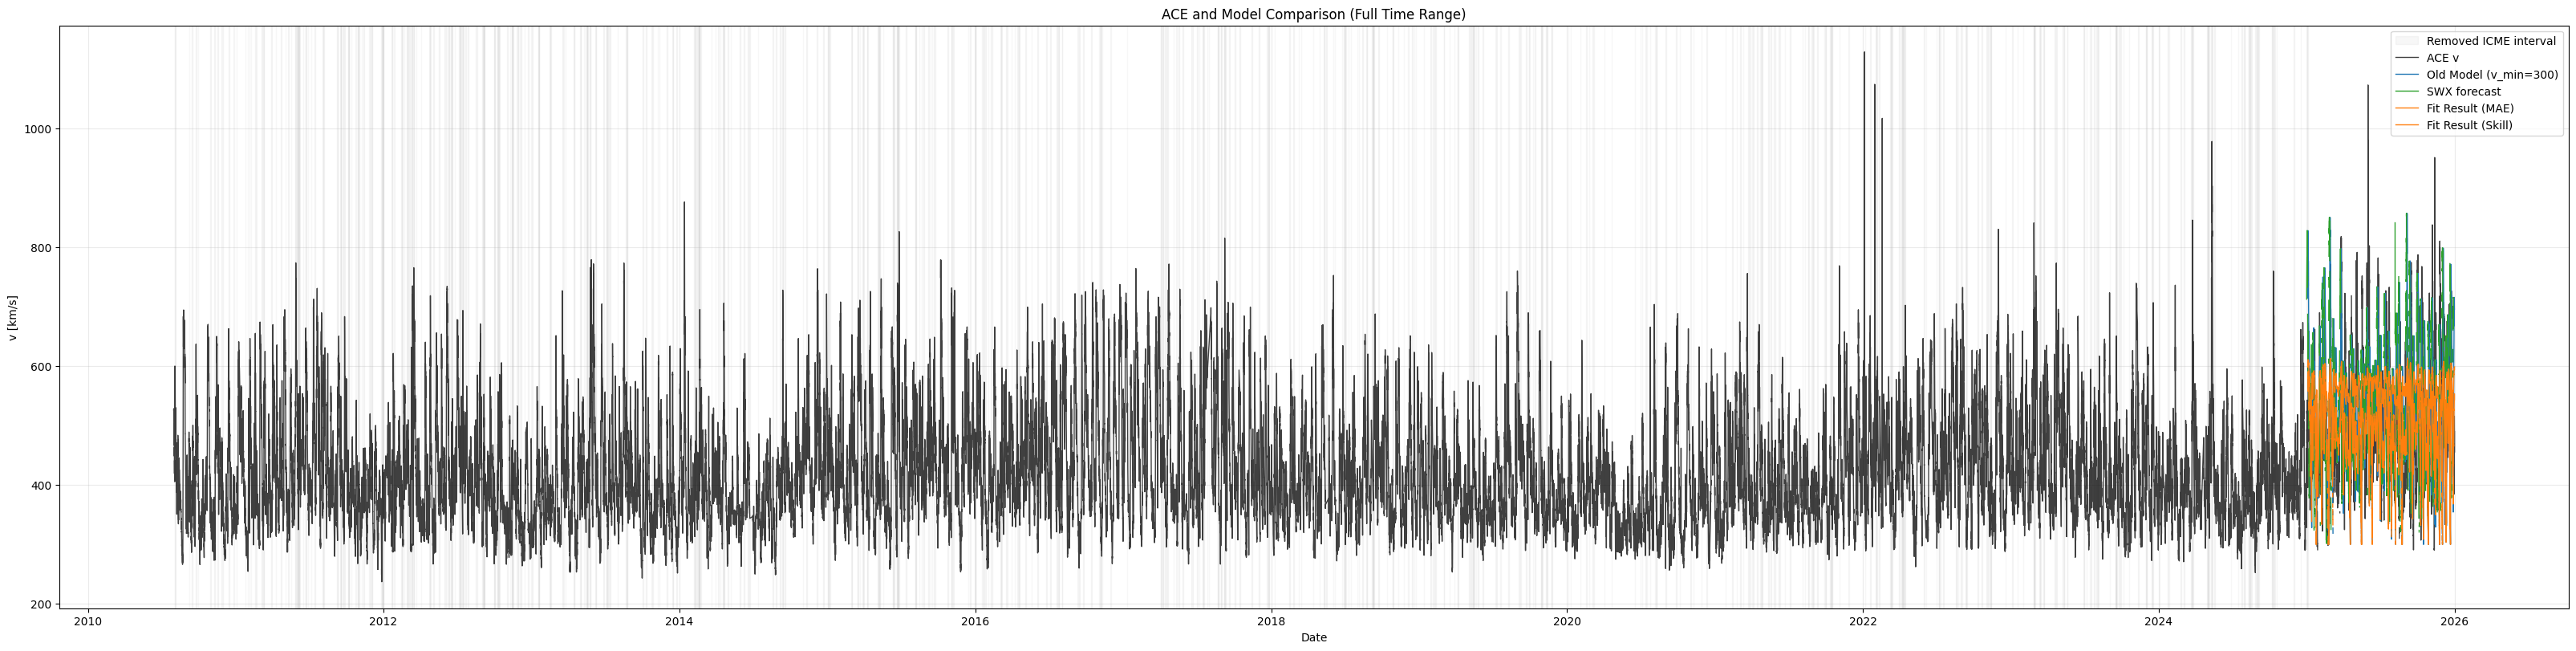

In [35]:
from Library.ICME import load_icme_windows

icme_windows = load_icme_windows()

fig, ax = plt.subplots(figsize=(32, 8), constrained_layout=True)

plotted_icme_label = False
for row in icme_windows.itertuples(index=False):
    if (
        row.end < old_fit_comparison.index.min()
        or row.start > old_fit_comparison.index.max()
    ):
        continue
    ax.axvspan(
        row.start,
        row.end,
        color="0.6",
        alpha=0.08,
        label="Removed ICME interval" if not plotted_icme_label else None,
    )
    plotted_icme_label = True

ax.plot(
    old_fit_comparison.index,
    old_fit_comparison["v_ace"],
    label="ACE v",
    color="black",
    linewidth=1.0,
    alpha=0.75,
)
ax.plot(
    old_fit_comparison.index,
    old_fit_comparison["v_forecast"],
    label=old_fit_params["label"],
    color="tab:blue",
    linewidth=1.0,
)
ax.plot(
    old_fit_comparison.index,
    old_fit_comparison["v_swx_forecast"],
    label="SWX forecast",
    color="tab:green",
    linewidth=1.0,
)
ax.plot(
    full_fit_comparison_mae.index,
    full_fit_comparison_mae["v_forecast"],
    label=full_fit_params_mae["label"],
    color="tab:orange",
    linewidth=1.0,
)
ax.plot(
    full_fit_comparison_skill.index,
    full_fit_comparison_skill["v_forecast"],
    label=full_fit_params_skill["label"],
    color="tab:orange",
    linewidth=1.0,
)
ax.set_title("ACE and Model Comparison (Full Time Range)")
ax.set_xlabel("Date")
ax.set_ylabel("v [km/s]")
ax.grid(alpha=0.25)
ax.legend(loc="upper right")
plt.show()

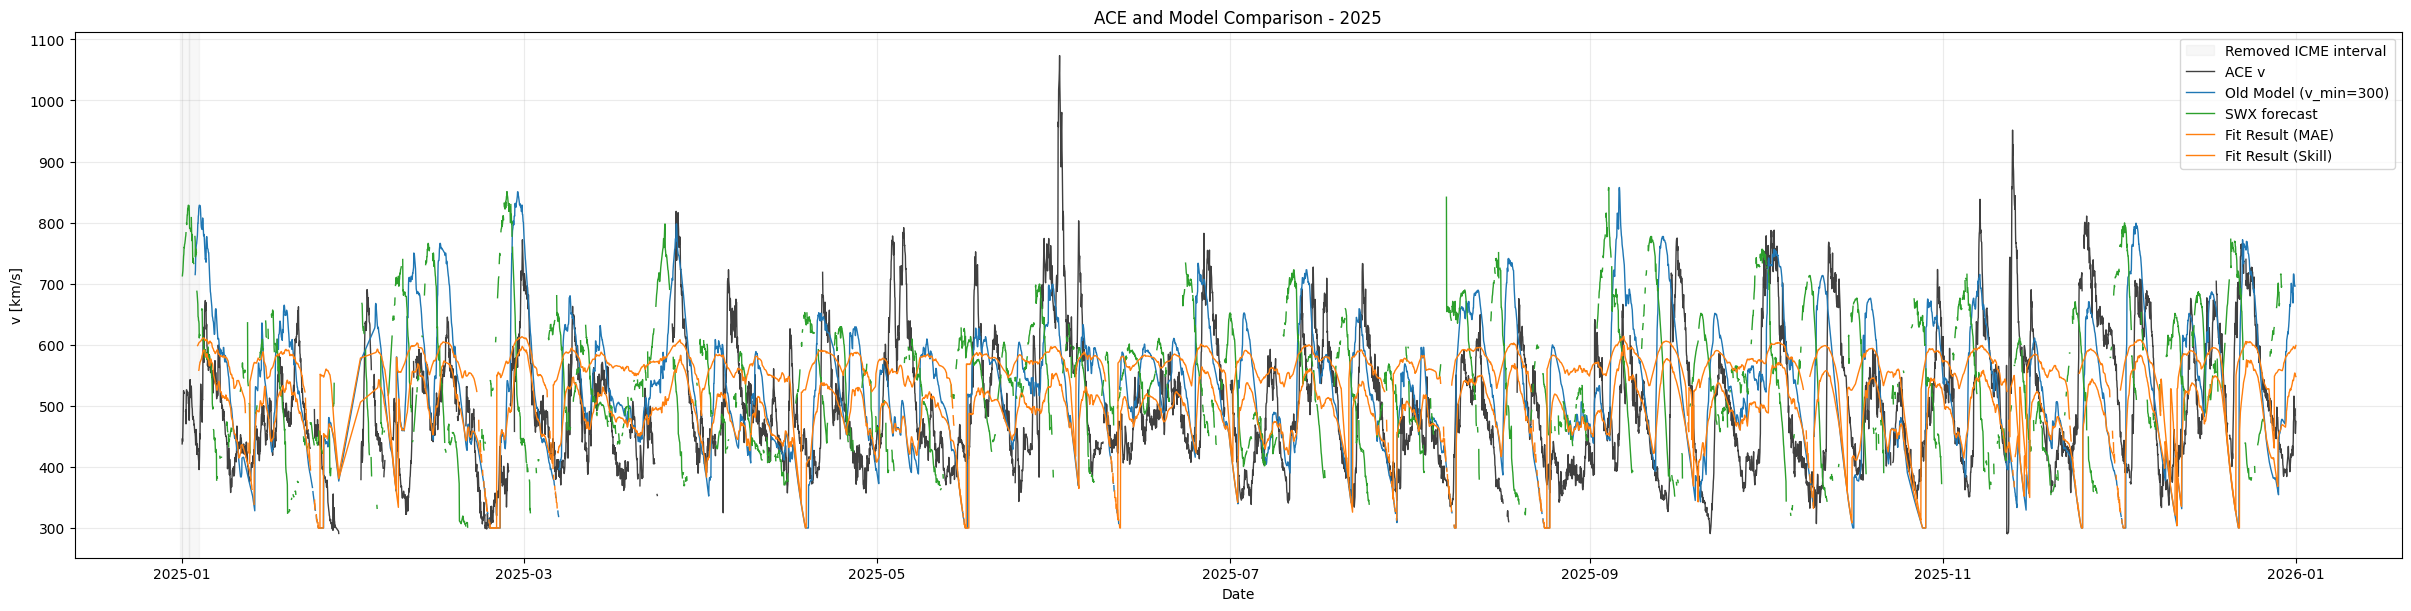

In [ ]:
from Library.ICME import load_icme_windows

icme_windows = load_icme_windows()

start_year = 2025
end_year = 2025

for year in range(start_year, end_year + 1):
    old_year = old_fit_comparison.loc[str(year)]
    full_year_mae = full_fit_comparison_mae.loc[str(year)]
    full_year_skill = full_fit_comparison_skill.loc[str(year)]

    fig, ax = plt.subplots(figsize=(24, 6), constrained_layout=True)
    plotted_icme_label = False
    year_start = old_year.index.min()
    year_end = old_year.index.max()
    for row in icme_windows.itertuples(index=False):
        if row.end < year_start or row.start > year_end:
            continue
        ax.axvspan(
            row.start,
            row.end,
            color="0.6",
            alpha=0.08,
            label="Removed ICME interval" if not plotted_icme_label else None,
        )
        plotted_icme_label = True
    ax.plot(
        old_year.index,
        old_year["v_ace"],
        label="ACE v",
        color="black",
        linewidth=1.0,
        alpha=0.75,
    )
    ax.plot(
        old_year.index,
        old_year["v_forecast"],
        label=old_fit_params["label"],
        color="tab:blue",
        linewidth=1.0,
    )
    ax.plot(
        old_year.index,
        old_year["v_swx_forecast"],
        label="SWX forecast",
        color="tab:green",
        linewidth=1.0,
    )
    ax.plot(
        full_year_mae.index,
        full_year_mae["v_forecast"],
        label=full_fit_params_mae["label"],
        color="tab:orange",
        linewidth=1.0,
    )
    ax.plot(
        full_year_skill.index,
        full_year_skill["v_forecast"],
        label=full_fit_params_skill["label"],
        color="tab:purple",
        linewidth=1.0,
    )
    ax.set_title(f"ACE and Model Comparison - {year}")
    ax.set_xlabel("Date")
    ax.set_ylabel("v [km/s]")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right")
    plt.show()
    plt.close(fig)

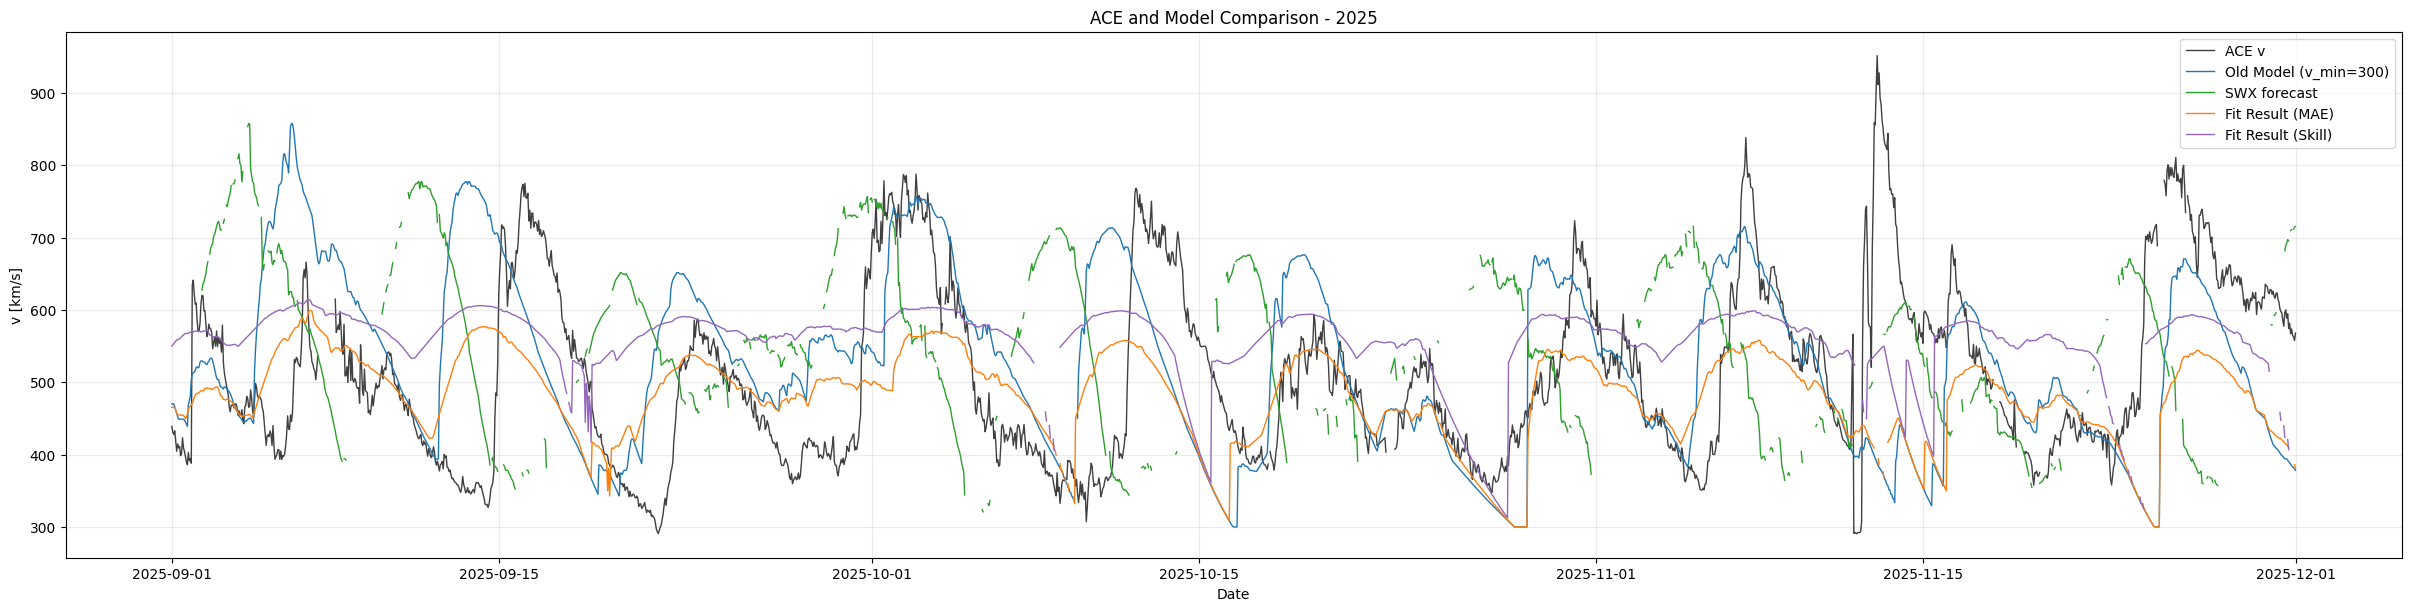

In [ ]:
old_year = old_fit_comparison["2025-09":"2025-11"]
full_year_mae = full_fit_comparison_mae["2025-09":"2025-11"]
full_year_skill = full_fit_comparison_skill["2025-09":"2025-11"]

fig, ax = plt.subplots(figsize=(24, 6), constrained_layout=True)
plotted_icme_label = False
year_start = old_year.index.min()
year_end = old_year.index.max()
for row in icme_windows.itertuples(index=False):
    if row.end < year_start or row.start > year_end:
        continue
    ax.axvspan(
        row.start,
        row.end,
        color="0.6",
        alpha=0.08,
        label="Removed ICME interval" if not plotted_icme_label else None,
    )
    plotted_icme_label = True
ax.plot(
    old_year.index,
    old_year["v_ace"],
    label="ACE v",
    color="black",
    linewidth=1.0,
    alpha=0.75,
)
ax.plot(
    old_year.index,
    old_year["v_forecast"],
    label=old_fit_params["label"],
    color="tab:blue",
    linewidth=1.0,
)
ax.plot(
    old_year.index,
    old_year["v_swx_forecast"],
    label="SWX forecast",
    color="tab:green",
    linewidth=1.0,
)
ax.plot(
    full_year_mae.index,
    full_year_mae["v_forecast"],
    label=full_fit_params_mae["label"],
    color="tab:orange",
    linewidth=1.0,
)
ax.plot(
    full_year_skill.index,
    full_year_skill["v_forecast"],
    label=full_fit_params_skill["label"],
    color="tab:purple",
    linewidth=1.0,
)
ax.set_title(f"ACE and Model Comparison - {year}")
ax.set_xlabel("Date")
ax.set_ylabel("v [km/s]")
ax.grid(alpha=0.25)
ax.legend(loc="upper right")
plt.show()
plt.close(fig)

/tmp/ipykernel_1511897/2749635990.py:1: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(


np.float64(nan)